In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(0.08, 0.10)
sample_size = NormalIndPower().solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    ratio=1
)
print(sample_size)


import math
sample_size_per_group = math.ceil(sample_size)
print(f"Required sample size per group: {sample_size_per_group}")
print(f"Total sample size needed: {sample_size_per_group * 2}")

3204.714799524207
Required sample size per group: 3205
Total sample size needed: 6410


6410
[   1    2    3 ... 6408 6409 6410]
['control' 'control' 'control' ... 'treatment' 'treatment' 'treatment']
6410
[0 1 0 ... 0 0 1]
6410
Index(['user_id', 'group', 'converted'], dtype='str')
   user_id    group  converted
0        1  control          0
1        2  control          1
2        3  control          0
3        4  control          0
4        5  control          0
Overall conversion rate: 0.0888
group
control      0.081747
treatment    0.095788
Name: converted, dtype: float64

Device type balance across groups:
device_type   desktop    mobile    tablet
group                                    
control      0.360998  0.543838  0.095164
treatment    0.341342  0.561310  0.097348

Traffic source balance across groups:
traffic_source   organic      paid    social
group                                       
control         0.453042  0.344150  0.202808
treatment       0.452730  0.347894  0.199376


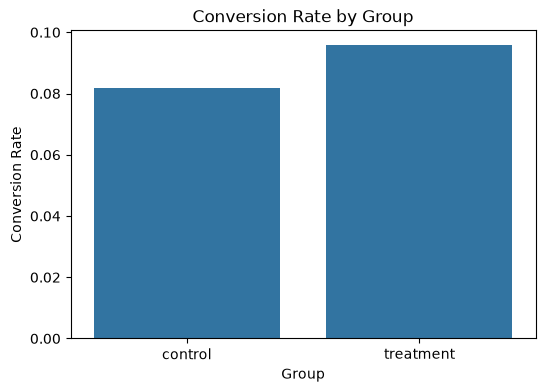

In [106]:
n_per_group = 3205
total_users = n_per_group * 2
print(total_users)

np.random.seed(42)

user_id = np.arange(1,total_users +1)
print(user_id)

group = np.repeat(['control', 'treatment'], n_per_group)
print(group)
print(len(group))


control_converted = np.random.binomial(n=1, p=0.08, size=n_per_group)
treatment_converted = np.random.binomial(n=1, p=0.10, size=n_per_group)

converted = np.concatenate([control_converted, treatment_converted])
print(converted)
print(len(converted))



df = pd.DataFrame({'user_id': user_id, 'group': group, 'converted': converted})
df.head()
df.shape

print(df.columns)
print(df.head())

df['group'].value_counts()
df.groupby('group')['converted'].mean()

df.sample(frac=1).reset_index(drop=True)

device_type = np.random.choice(['mobile', 'desktop', 'tablet'], size=len(df), p=[0.55, 0.35, 0.10])
traffic_source = np.random.choice(['organic', 'paid', 'social'], size=len(df), p=[0.45, 0.35, 0.20])

df['device_type'] = device_type
df['traffic_source'] = traffic_source

df.head()
df.shape


df['converted'].mean()



overall_rate = df['converted'].mean()
print(f"Overall conversion rate: {overall_rate:.4f}")


conversion_by_group = df.groupby('group')['converted'].mean()
print(conversion_by_group)

device_balance = pd.crosstab(df['group'], df['device_type'], normalize='index')
traffic_balance = pd.crosstab(df['group'], df['traffic_source'], normalize='index')

print("\nDevice type balance across groups:")
print(device_balance)

print("\nTraffic source balance across groups:")
print(traffic_balance)

# Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x=conversion_by_group.index, y=conversion_by_group.values)
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Group')
plt.show()

Control conversions: 262/3205
Treatment conversions: 307/3205
Z-statistic: -1.9762
P-value: 0.0481
95% CI for difference (treatment - control): (0.0001, 0.0280)
Control rate: 0.0817
Treatment rate: 0.0958
Absolute lift: 1.40 percentage points
Relative lift: 17.18%
device_type  group    
desktop      control      0.090752
             treatment    0.091408
mobile       control      0.076305
             treatment    0.100611
tablet       control      0.078689
             treatment    0.083333
Name: converted, dtype: float64
traffic_source  group    
organic         control      0.075758
                treatment    0.099931
paid            control      0.087942
                treatment    0.092377
social          control      0.084615
                treatment    0.092332
Name: converted, dtype: float64
group
control      50.354809
treatment    50.401694
Name: order_value, dtype: float64
Control AOV: mean=50.35, n=262
Treatment AOV: mean=50.40, n=307
T-statistic: -0.0390
P-value: 0.96

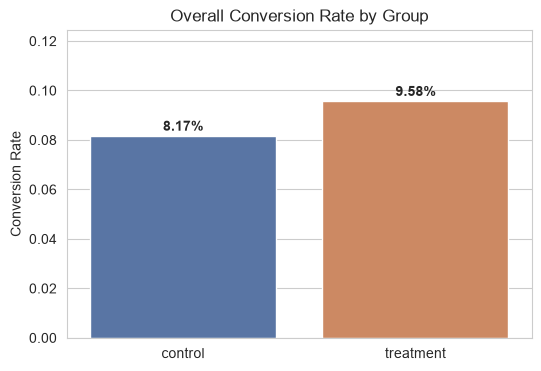

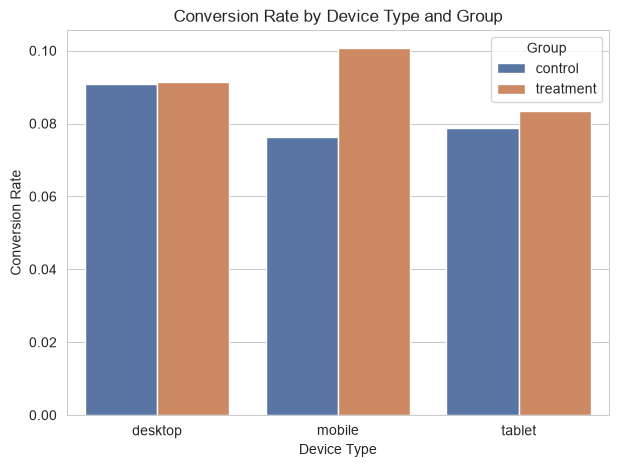

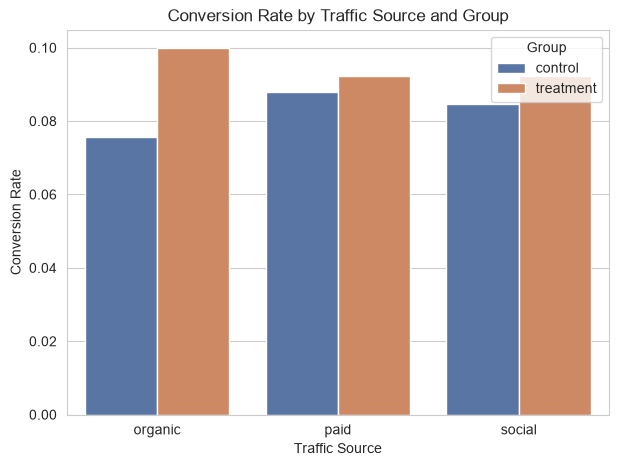

In [119]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts of conversions and total users per group
control_conversions = df[df['group'] == 'control']['converted'].sum()
treatment_conversions = df[df['group'] == 'treatment']['converted'].sum()

control_total = df[df['group'] == 'control'].shape[0]
treatment_total = df[df['group'] == 'treatment'].shape[0]

# Run the z-test
count = [control_conversions, treatment_conversions]
nobs = [control_total, treatment_total]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Control conversions: {control_conversions}/{control_total}")
print(f"Treatment conversions: {treatment_conversions}/{treatment_total}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")



from statsmodels.stats.proportion import confint_proportions_2indep

# Confidence interval for the difference in proportions
ci_low, ci_upp = confint_proportions_2indep(
    count1=treatment_conversions, nobs1=treatment_total,
    count2=control_conversions, nobs2=control_total,
    method='wald'
)

print(f"95% CI for difference (treatment - control): ({ci_low:.4f}, {ci_upp:.4f})")

# Relative lift
control_rate = control_conversions / control_total
treatment_rate = treatment_conversions / treatment_total
relative_lift = (treatment_rate - control_rate) / control_rate * 100

print(f"Control rate: {control_rate:.4f}")
print(f"Treatment rate: {treatment_rate:.4f}")
print(f"Absolute lift: {(treatment_rate - control_rate)*100:.2f} percentage points")
print(f"Relative lift: {relative_lift:.2f}%")



device_segment = df.groupby(['device_type', 'group'])['converted'].mean()
print(device_segment)

traffic_segment = df.groupby(['traffic_source', 'group'])['converted'].mean()
print(traffic_segment)


# Initialize order_value column with NaN for everyone
df['order_value'] = np.nan

# Only assign an order value to users who converted
converted_mask = df['converted'] == 1
n_converted = converted_mask.sum()

# Simulate order values using a normal distribution (mean=$50, std=$15)
df.loc[converted_mask, 'order_value'] = np.random.normal(loc=50, scale=15, size=n_converted).round(2)

# Check AOV by group (only among converters)
aov_by_group = df[df['converted'] == 1].groupby('group')['order_value'].mean()
print(aov_by_group)


from scipy import stats

control_aov = df[(df['group'] == 'control') & (df['converted'] == 1)]['order_value']
treatment_aov = df[(df['group'] == 'treatment') & (df['converted'] == 1)]['order_value']

t_stat, p_value = stats.ttest_ind(control_aov, treatment_aov)

print(f"Control AOV: mean={control_aov.mean():.2f}, n={len(control_aov)}")
print(f"Treatment AOV: mean={treatment_aov.mean():.2f}, n={len(treatment_aov)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")




sns.set_style('whitegrid')

# 1. Overall conversion rate by group
plt.figure(figsize=(6,4))
overall = df.groupby('group')['converted'].mean().reset_index()
sns.barplot(data=overall, x='group', y='converted', hue='group', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Overall Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.xlabel('')
plt.ylim(0, max(overall['converted'])*1.3)
for i, v in enumerate(overall['converted']):
    plt.text(i, v + 0.002, f"{v:.2%}", ha='center', fontweight='bold')
plt.savefig('chart_name1.png')
plt.show()


# 2. Conversion rate by device_type, split by group
plt.figure(figsize=(7,5))
device_data = df.groupby(['device_type', 'group'])['converted'].mean().reset_index()
sns.barplot(data=device_data, x='device_type', y='converted', hue='group', palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Device Type and Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Device Type')
plt.legend(title='Group')
plt.savefig('chart_name2.png')
plt.show()

# 3. Conversion rate by traffic_source, split by group
plt.figure(figsize=(7,5))
traffic_data = df.groupby(['traffic_source', 'group'])['converted'].mean().reset_index()
sns.barplot(data=traffic_data, x='traffic_source', y='converted', hue='group', palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Traffic Source and Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Traffic Source')
plt.legend(title='Group')
plt.savefig('chart_name3.png')
plt.show()



df.to_csv('ab_test_data.csv', index=False)